# Problem 3 — 2D Advection

Solve the 2D advection equation
$$
\frac{\partial u}{\partial t} + a\frac{\partial u}{\partial x} + b\frac{\partial u}{\partial y} = 0,
\quad (x,y)\in[0,1]^2, \quad a=1,\; b=2
$$
with double-periodic BC and Gaussian IC
$$
u(0,x,y) = \exp\!\left(-\frac{(x-\tfrac12)^2+(y-\tfrac12)^2}{(3/20)^2}\right).
$$
CFL number $C=0.5$, so $\Delta t = C\,\Delta x / \sqrt{a^2+b^2}$,
giving $\mu = a\Delta t/\Delta x \approx 0.2236$ and $\nu = b\Delta t/\Delta y \approx 0.4472$.

Two methods are compared across $N\in\{128, 256, 512\}$:
- **CTU** (Corner Transport Upstream, 1st-order in space and time)
- **LW** (Lax–Wendroff, 2nd-order in space and time)

Time loop uses `jax.lax.scan` for a single XLA compilation per segment.

In [2]:
import jax
jax.config.update('jax_enable_x64', True)
try:
    jax.config.update('jax_platform_name', 'gpu')
    _ = jax.devices('gpu')
    print('Using GPU:', jax.devices('gpu'), flush=True)
except RuntimeError:
    jax.config.update('jax_platform_name', 'cpu')
    print('GPU not available, using CPU.', flush=True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from Problem3 import (
    PS4_Problem3,
    ctu_step, lax_wendroff_step,
    analytical_solution, initial_condition,
    get_L2_error,
    A, B,
)

Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]


## (a) Analytical Solution

For constant coefficients $a, b$ and periodic BC, the PDE is solved by the method of characteristics.
The characteristic curves are $x(t)=x_0+at$, $y(t)=y_0+bt$, along which $u$ is constant:
$$
u(t,x,y) = u\!\left(0,\,(x-at)\bmod 1,\,(y-bt)\bmod 1\right).
$$
Substituting into the PDE confirms this:
$\partial_t u = -a\,\partial_x u_0 - b\,\partial_y u_0$ and
$a\,\partial_x u + b\,\partial_y u = a\,\partial_x u_0 + b\,\partial_y u_0$, so the sum is zero. $\square$

Since $a=1$ and $b=2$, the solution is periodic with period $T=1$ in time
(the Gaussian returns to its initial position at every integer $t$).

Initialized PS4_Problem3: N=256, dt=8.73464e-04, μ=0.2236, ν=0.4472


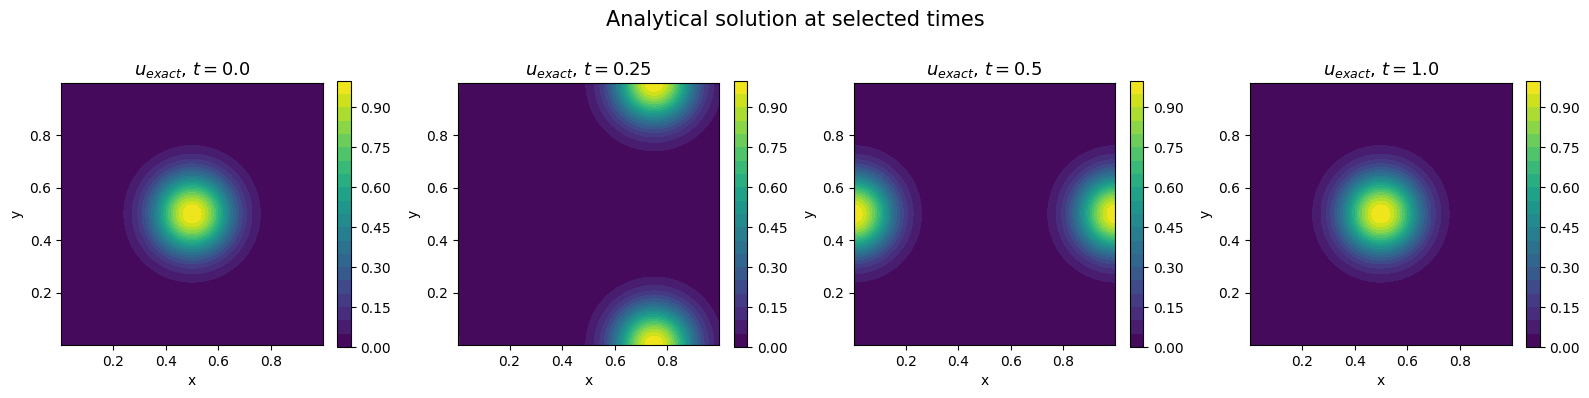

In [3]:
# Visualise the IC and analytical solution at t=0.25, 0.5, 1.0 on a fine grid
N_fine = 256
p_fine = PS4_Problem3(N=N_fine)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
X_np = jax.device_get(p_fine.X)
Y_np = jax.device_get(p_fine.Y)

for ax, t_plot in zip(axes, [0.0, 0.25, 0.5, 1.0]):
    u_exact = jax.device_get(analytical_solution(p_fine.X, p_fine.Y, t_plot, A, B))
    cf = ax.contourf(X_np, Y_np, u_exact, levels=20, cmap='viridis', vmin=0, vmax=1)
    fig.colorbar(cf, ax=ax, fraction=0.046)
    ax.set_title(f'$u_{{exact}}$, $t={t_plot}$', fontsize=13)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')

fig.suptitle('Analytical solution at selected times', fontsize=15)
plt.tight_layout()
plt.show()

## (b) CTU and Lax–Wendroff Schemes

### CTU (Corner Transport Upstream)

Project the exact solution (piecewise-constant IC) back to the initial mesh.
For $\mu,\nu\in[0,1]$ the exact solution at time $\Delta t$ falls in cell
$(i{-}1,j{-}1)\text{–}(i,j)$, giving the bilinear projection:
$$
u^{n+1}_{i,j} = (1{-}\mu)(1{-}\nu)\,u^n_{i,j}
               + \mu(1{-}\nu)\,u^n_{i-1,j}
               + (1{-}\mu)\nu\,u^n_{i,j-1}
               + \mu\nu\,u^n_{i-1,j-1}.
$$
**Stability**: $\mu+\nu\le1$ (satisfied here: $\mu+\nu\approx0.671$).
**Accuracy**: $O(\Delta t,\Delta x, \Delta y)$ — first-order.

### Lax–Wendroff

Second-order Taylor expansion in time, with time derivatives replaced by spatial
derivatives via the PDE:
$$
u^{n+1}_{i,j} = u^n_{i,j}
  -\frac{\mu}{2}(u_{i+1,j}-u_{i-1,j})
  -\frac{\nu}{2}(u_{i,j+1}-u_{i,j-1})
  +\frac{\mu^2}{2}(u_{i+1,j}-2u_{i,j}+u_{i-1,j})
  +\frac{\nu^2}{2}(u_{i,j+1}-2u_{i,j}+u_{i,j-1})
  +\frac{\mu\nu}{4}(u_{i+1,j+1}-u_{i+1,j-1}-u_{i-1,j+1}+u_{i-1,j-1}).
$$
**Accuracy**: $O(\Delta t^2, \Delta x^2, \Delta y^2)$ — second-order.

### Modified equation (leading-order error)

For **CTU**, Taylor-expanding gives the modified PDE:
$$
\partial_t u + a\partial_x u + b\partial_y u
= \tfrac{\Delta x}{2}(1-\mu)\,a\,\partial_{xx}u
+ \tfrac{\Delta y}{2}(1-\nu)\,b\,\partial_{yy}u
+ \mu\nu\Delta x\,ab\,\partial_{xy}u + O(\Delta^2).
$$
The dominant error is **numerical diffusion** ($O(\Delta x)$), which smears the Gaussian.

For **Lax–Wendroff**, the $O(\Delta x^2)$ terms cancel by design; the leading error is
**numerical dispersion** ($O(\Delta x^2)$), producing phase errors and oscillations near sharp gradients.

## (c) Numerical Evolution: $N = 128, 256, 512$, $t\in[0,10]$

Each run uses `jax.lax.scan` — the entire time loop compiles to a single XLA kernel,
running efficiently on GPU.
Two scan stages (0→1, 1→10) capture the $t=1$ and $t=10$ snapshots without
storing the full trajectory.

In [4]:
Ns = [128, 256, 512]
results = {}

for method in ['CTU', 'LW']:
    results[method] = {}
    for N in Ns:
        print(f"\n{'='*50}")
        p = PS4_Problem3(N=N)
        results[method][N] = p.solve(t_stop=10.0, method=method)
        results[method][N]['solver'] = p   # keep solver for grid access


Initialized PS4_Problem3: N=128, dt=1.74693e-03, μ=0.2236, ν=0.4472
[CTU] N=128, N_total=5724, dt=1.747e-03, μ=0.2236, ν=0.4472
  t = 0 → 1       done,  L2(t=1)       = 5.865e-02
  t = 1 → 10.0  done,  L2(t=10.0) = 1.550e-01

Initialized PS4_Problem3: N=256, dt=8.73464e-04, μ=0.2236, ν=0.4472
[CTU] N=256, N_total=11449, dt=8.735e-04, μ=0.2236, ν=0.4472
  t = 0 → 1       done,  L2(t=1)       = 3.506e-02
  t = 1 → 10.0  done,  L2(t=10.0) = 1.299e-01

Initialized PS4_Problem3: N=512, dt=4.36732e-04, μ=0.2236, ν=0.4472
[CTU] N=512, N_total=22897, dt=4.367e-04, μ=0.2236, ν=0.4472
  t = 0 → 1       done,  L2(t=1)       = 1.945e-02
  t = 1 → 10.0  done,  L2(t=10.0) = 9.914e-02

Initialized PS4_Problem3: N=128, dt=1.74693e-03, μ=0.2236, ν=0.4472
[LW] N=128, N_total=5724, dt=1.747e-03, μ=0.2236, ν=0.4472
  t = 0 → 1       done,  L2(t=1)       = 3.867e-03
  t = 1 → 10.0  done,  L2(t=10.0) = 3.778e-02

Initialized PS4_Problem3: N=256, dt=8.73464e-04, μ=0.2236, ν=0.4472
[LW] N=256, N_total=11449,

### $L_2$ error vs time

At every time step the $L_2$ error $\|u_h - u_{\text{exact}}\|_2 = \sqrt{\langle(u_h-u_{\text{exact}})^2\rangle}$
is recorded. Since the analytical solution is periodic with period 1 in time, the error at integer
times $t=1,2,\ldots$ reflects only the accumulated numerical diffusion/dispersion — **not** the
phase shift. CTU accumulates diffusion monotonically; LW grows more slowly due to second-order accuracy.

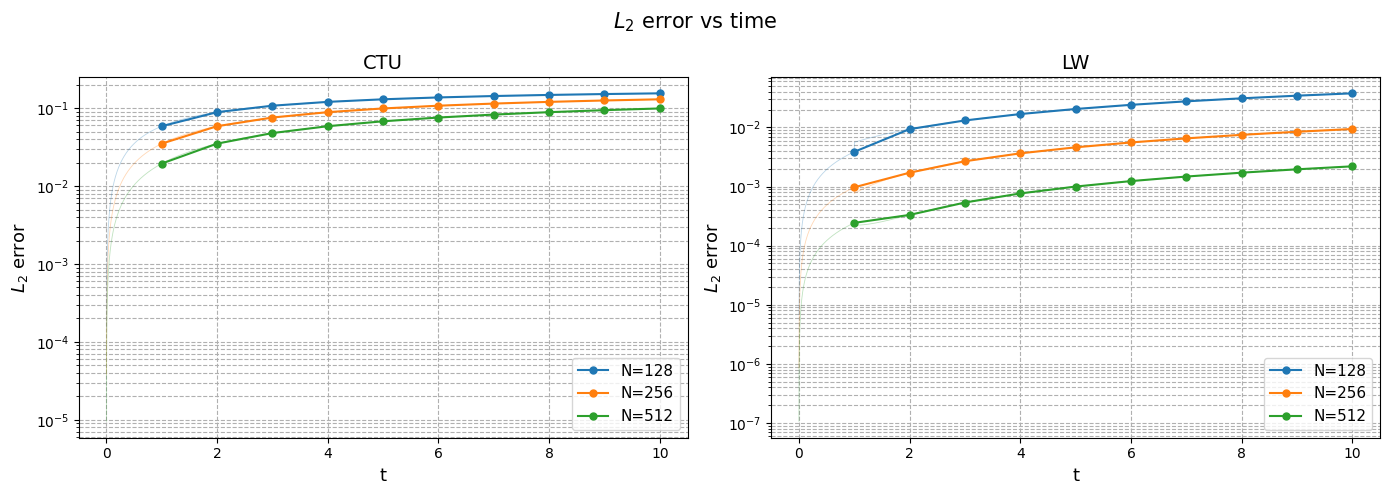

In [5]:
colors = {128: 'tab:blue', 256: 'tab:orange', 512: 'tab:green'}

fig, (ax_ctu, ax_lw) = plt.subplots(1, 2, figsize=(14, 5))

for ax, method in [(ax_ctu, 'CTU'), (ax_lw, 'LW')]:
    for N in Ns:
        res  = results[method][N]
        t_np = jax.device_get(res['t_all'])
        l2   = jax.device_get(res['l2_all'])
        # Sample at integer times for markers
        t_int  = np.arange(1, 11, dtype=float)
        l2_int = np.array([float(l2[np.argmin(np.abs(t_np - ti))]) for ti in t_int])
        ax.plot(t_np, l2, lw=0.6, alpha=0.3, color=colors[N])
        ax.plot(t_int, l2_int, 'o-', ms=5, color=colors[N], label=f'N={N}')
    ax.set_xlabel('t', fontsize=13)
    ax.set_ylabel('$L_2$ error', fontsize=13)
    ax.set_yscale('log')
    ax.set_title(method, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', ls='--')

fig.suptitle('$L_2$ error vs time', fontsize=15)
plt.tight_layout()
plt.show()

### Contour plots of $u(x,y)$ at $t=1$ and $t=10$

At $t=1$ the Gaussian has completed one full advection period, so the exact solution
is identical to the IC. Any broadening (CTU) or ringing (LW) is purely numerical.
At $t=10$ ten periods have elapsed and the errors have accumulated.

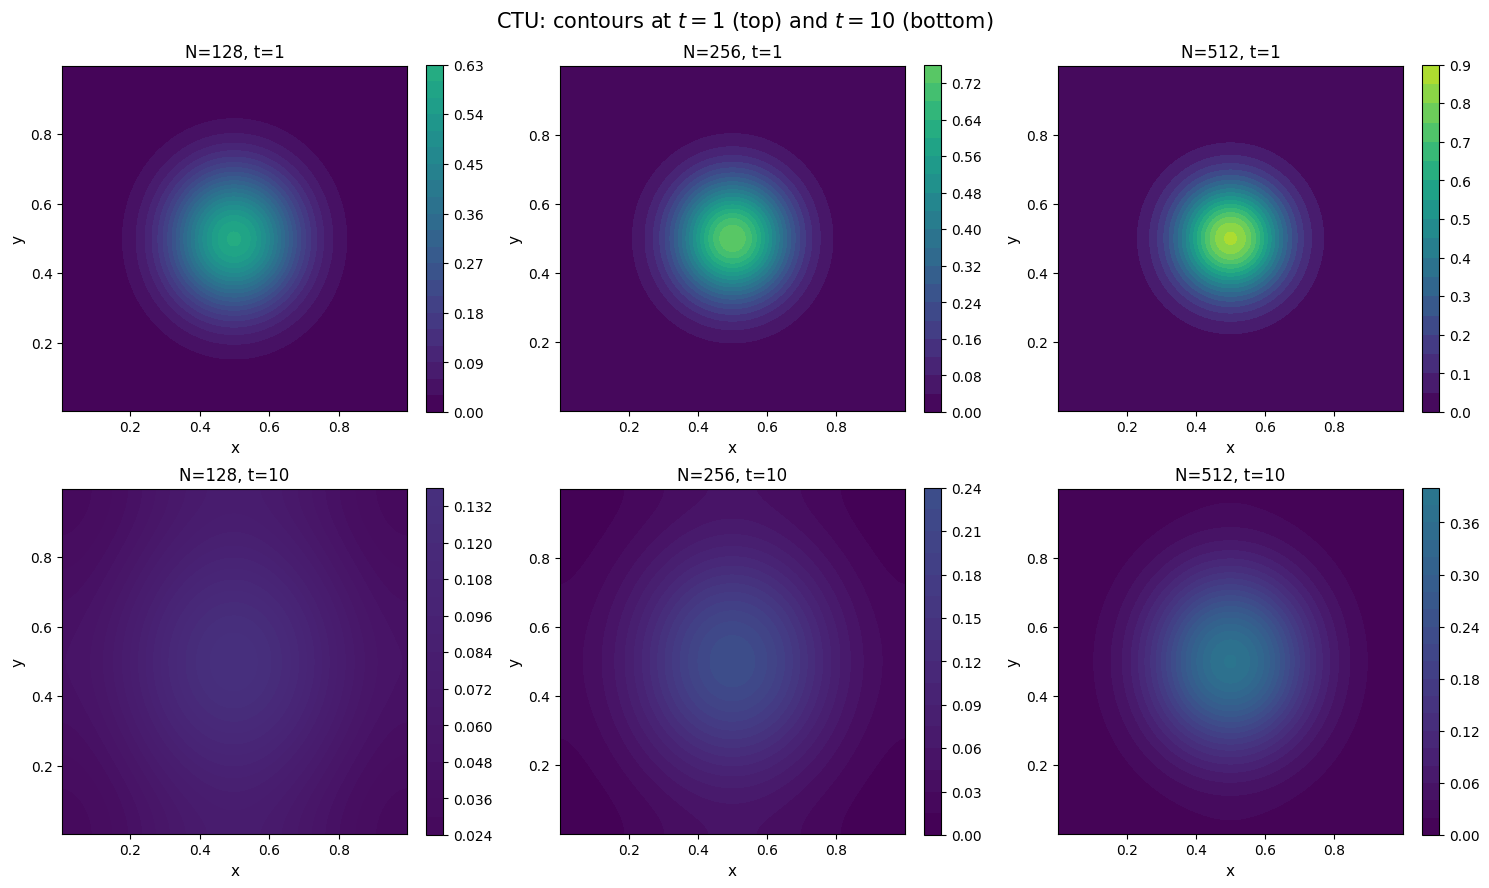

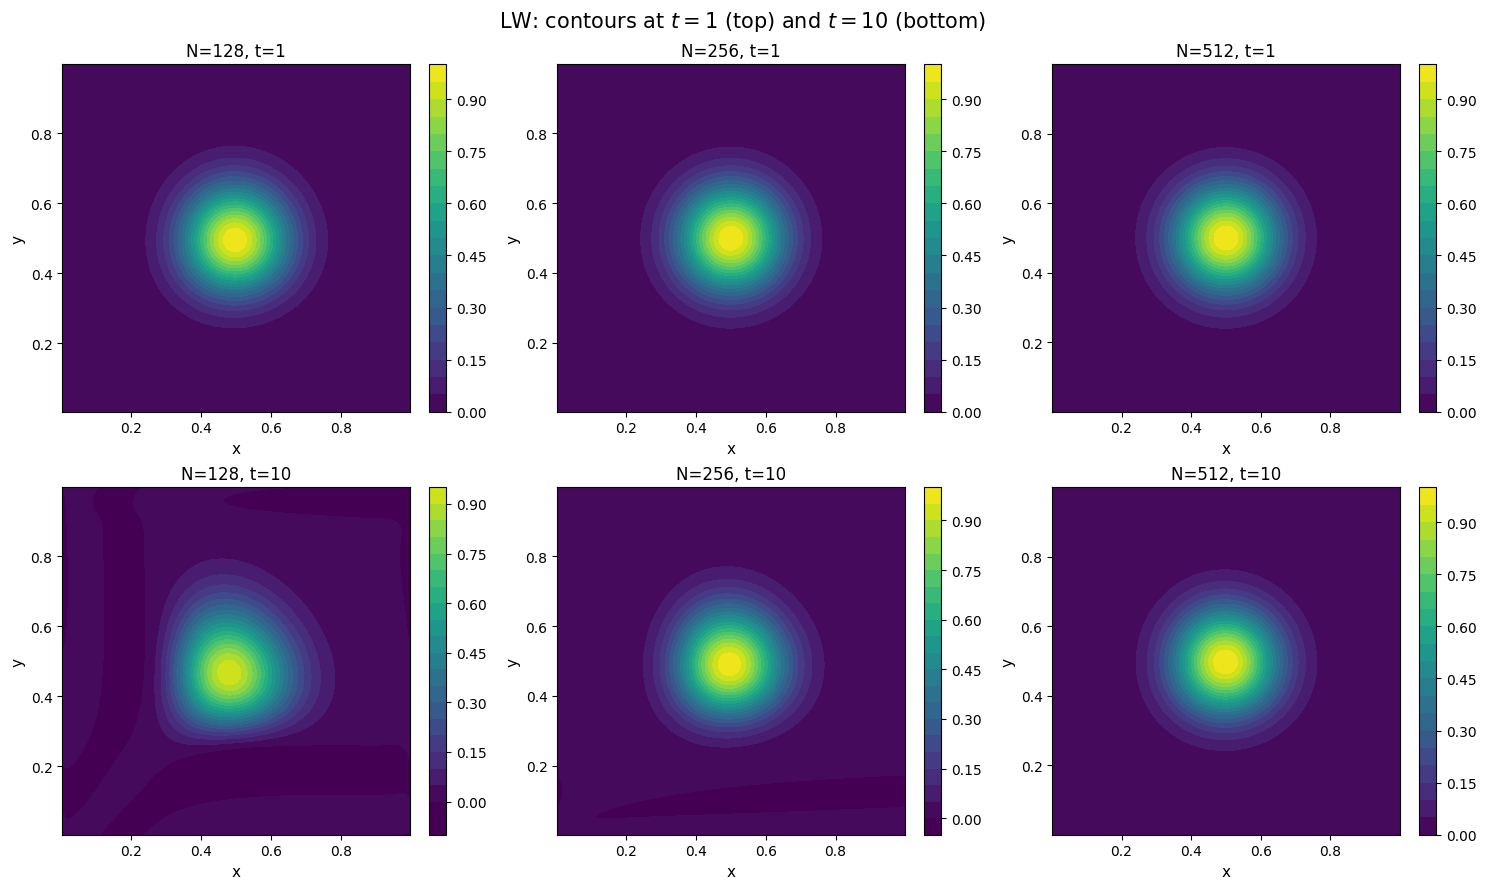

In [6]:
for method in ['CTU', 'LW']:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(f'{method}: contours at $t=1$ (top) and $t=10$ (bottom)', fontsize=15)

    for col, N in enumerate(Ns):
        res    = results[method][N]
        solver = res['solver']
        X_np   = jax.device_get(solver.X)
        Y_np   = jax.device_get(solver.Y)

        for row, (u_key, tlabel) in enumerate([('u_at_1', 't=1'), ('u_at_final', 't=10')]):
            ax  = axes[row][col]
            u_np = jax.device_get(res[u_key])
            cf   = ax.contourf(X_np, Y_np, u_np, levels=20, cmap='viridis', vmin=0, vmax=1)
            fig.colorbar(cf, ax=ax, fraction=0.046)
            ax.set_title(f'N={N}, {tlabel}', fontsize=12)
            ax.set_xlabel('x', fontsize=11)
            ax.set_ylabel('y', fontsize=11)
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(f'p3_contours_{method}.png', dpi=120)
    plt.show()

### Method comparison at fixed $N=256$

CTU diffuses the Gaussian (peak decreases, width increases) while Lax–Wendroff
preserves the shape better but develops small oscillations at sharp gradients.
The cross-section below confirms the qualitative difference at $t=10$.

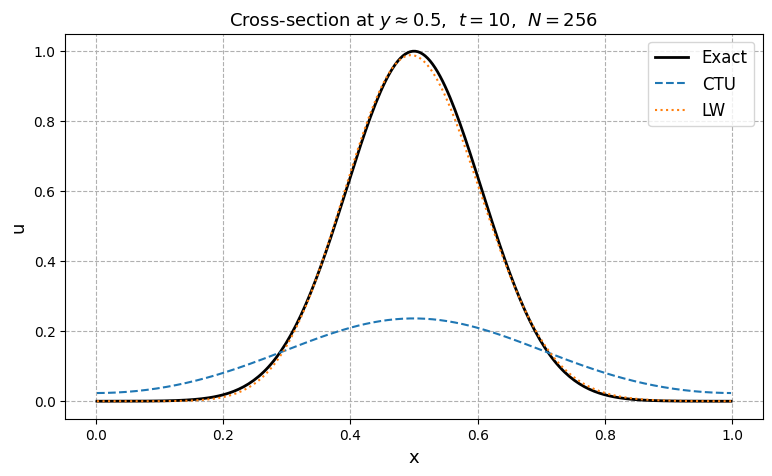

In [10]:
N_compare = 256
solver_ref = results['CTU'][N_compare]['solver']
X_np = jax.device_get(solver_ref.X)
x_1d = X_np[:, N_compare // 2]   # cross-section at y ≈ 0.5

u_exact_t10 = jax.device_get(
    analytical_solution(solver_ref.X, solver_ref.Y, 10.0, A, B)
)[:, N_compare // 2]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_1d, u_exact_t10, 'k-', lw=2, label='Exact')
for method, ls in [('CTU', '--'), ('LW', ':')]:
    u_t10 = jax.device_get(
        results[method][N_compare]['u_at_final']
    )[:, N_compare // 2]
    ax.plot(x_1d, u_t10, ls, lw=1.5, label=method)

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('u', fontsize=13)
ax.set_title(f'Cross-section at $y\\approx0.5$,  $t=10$,  $N={N_compare}$', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, ls='--')
#plt.tight_layout()
plt.show()

### Cross-section evolution at $y \approx 0.5$, $t = 0, 1, \ldots, 10$

Lines colored from blue ($t=0$) to cyan ($t=10$) via `cmap='winter'`.

  [CTU] snapshot t=1


/tmp/ipykernel_898231/2129648210.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_winter = cm.get_cmap('winter')


  [CTU] snapshot t=2
  [CTU] snapshot t=3
  [CTU] snapshot t=4
  [CTU] snapshot t=5
  [CTU] snapshot t=6
  [CTU] snapshot t=7
  [CTU] snapshot t=8
  [CTU] snapshot t=9
  [CTU] snapshot t=10
  [CTU] snapshot t=1
  [CTU] snapshot t=2
  [CTU] snapshot t=3
  [CTU] snapshot t=4
  [CTU] snapshot t=5
  [CTU] snapshot t=6
  [CTU] snapshot t=7
  [CTU] snapshot t=8
  [CTU] snapshot t=9
  [CTU] snapshot t=10
  [CTU] snapshot t=1
  [CTU] snapshot t=2
  [CTU] snapshot t=3
  [CTU] snapshot t=4
  [CTU] snapshot t=5
  [CTU] snapshot t=6
  [CTU] snapshot t=7
  [CTU] snapshot t=8
  [CTU] snapshot t=9
  [CTU] snapshot t=10


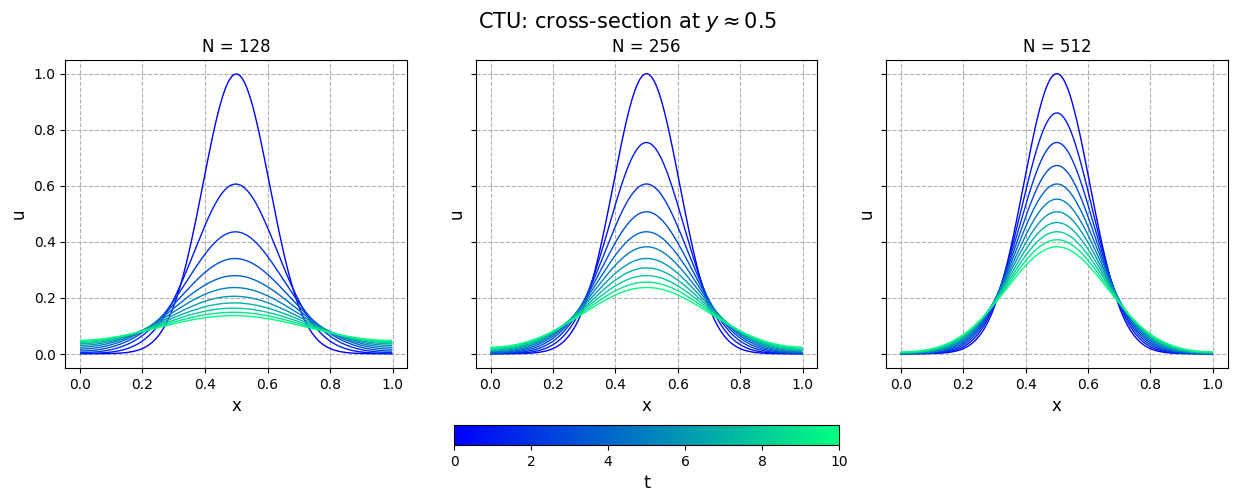

  [LW] snapshot t=1
  [LW] snapshot t=2
  [LW] snapshot t=3
  [LW] snapshot t=4
  [LW] snapshot t=5
  [LW] snapshot t=6
  [LW] snapshot t=7
  [LW] snapshot t=8
  [LW] snapshot t=9
  [LW] snapshot t=10
  [LW] snapshot t=1
  [LW] snapshot t=2
  [LW] snapshot t=3
  [LW] snapshot t=4
  [LW] snapshot t=5
  [LW] snapshot t=6
  [LW] snapshot t=7
  [LW] snapshot t=8
  [LW] snapshot t=9
  [LW] snapshot t=10
  [LW] snapshot t=1
  [LW] snapshot t=2
  [LW] snapshot t=3
  [LW] snapshot t=4
  [LW] snapshot t=5
  [LW] snapshot t=6
  [LW] snapshot t=7
  [LW] snapshot t=8
  [LW] snapshot t=9
  [LW] snapshot t=10


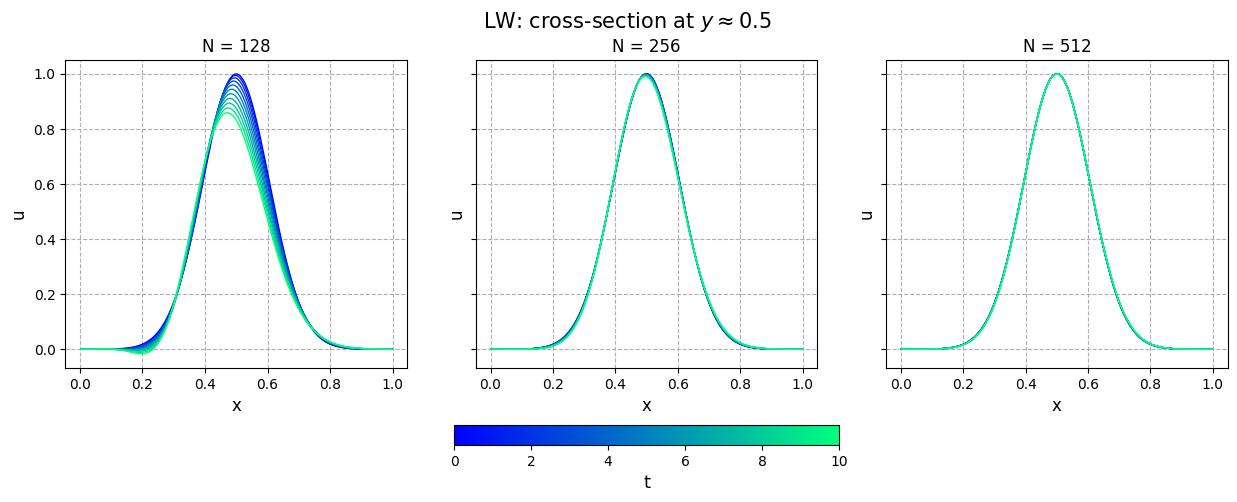

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

cmap_winter = cm.get_cmap('winter')
t_integers  = np.arange(0, 11)   # t = 0, 1, …, 10
norm        = mcolors.Normalize(vmin=0, vmax=10)

for method in ['CTU', 'LW']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    fig.suptitle(f'{method}: cross-section at $y \\approx 0.5$', fontsize=15)

    for col, N in enumerate(Ns):
        ax = axes[col]
        p  = results[method][N]['solver']

        # Snapshots at t = 0, 1, …, 10
        snaps = p.get_integer_snapshots(t_stop=10.0, method=method)

        x_1d = jax.device_get(p.X[:, N // 2])

        for t_val in t_integers:
            u_slice = jax.device_get(snaps[t_val])[:, N // 2]
            ax.plot(x_1d, u_slice, color=cmap_winter(norm(t_val)), lw=1.0)

        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('u', fontsize=12)
        ax.set_title(f'N = {N}', fontsize=12)
        ax.grid(True, ls='--')

    sm = cm.ScalarMappable(cmap=cmap_winter, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='horizontal',
                        location='bottom', fraction=0.05, pad=0.15, shrink=0.6)
    cbar.set_label('t', fontsize=13)

    #plt.tight_layout()
    plt.savefig(f'p3_crosssection_{method}.png', dpi=120)
    plt.show()